# Stitching redesign, step 3: one affine from edge displacements

If the camera is rotated (and the pixel size slightly off) relative to
the stage, every step in a given direction lands at the same wrong offset.
One 2x2 matrix A captures that: measured displacement = A x nominal
displacement. Fitted on displacements, not on absolute positions, so there
is no translation term to absorb the signal.

In [1]:
import os, sys, json, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# notebooks/tests/<subfolder>/ is three levels under the repo root.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))
sys.path.insert(0, os.getcwd())
import stitching_redesign_lib as L

NOTEBOOK_NAME = "stitching_redesign_step_03_fit_affine"
# Local data copy shared by every stitching_redesign_step_NN notebook
# (written by step 01; source: BC555_sample_05/epi, cells round).
DATA_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "stitching_redesign" / "data"
FIG_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "explanation" / "figures" / NOTEBOOK_NAME
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TITLE_FS, LABEL_FS, TICK_FS, LEGEND_FS = 14, 12, 11, 10
plt.rcParams.update({"axes.titlesize": TITLE_FS, "axes.labelsize": LABEL_FS,
                     "xtick.labelsize": TICK_FS, "ytick.labelsize": TICK_FS,
                     "legend.fontsize": LEGEND_FS})
DIR_COLORS = {"right": "#1f77b4", "left": "#ff7f0e", "up": "#2ca02c", "down": "#d62728"}


def save(fig, stem):
    path = FIG_DIR / f"{stem}.png"
    fig.savefig(path, dpi=110, bbox_inches="tight")
    print("saved", path.relative_to(MERCI_DIR))


In [2]:
geom = json.loads((DATA_DIR / "geometry.json").read_text())
PX, STEP, FRAME = geom["pixel_um"], geom["step_um"], geom["frame_px"]
nominal = np.loadtxt(DATA_DIR / "positions.txt", delimiter=",")
NBHD = np.array(geom["neighbourhood"])          # 3x3 FOV ids, row 0 = top
new_df = pd.read_csv(DATA_DIR / "edges_remeasured.csv")
edges = L.Edges(new_df, nominal)
print(f"{len(nominal)} FOVs, {len(new_df)} edges, pixel {PX} um, step {STEP:.3f} um, "
      f"3x3 centre FOV {NBHD[1, 1]}")


476 FOVs, 894 edges, pixel 0.109 um, step 199.066 um, 3x3 centre FOV 221


In [3]:
def draw_edges(ax, P, idx, values, cmap, vmin, vmax, lw=2.0):
    """Segments between FOV centres for edges idx, coloured by values."""
    half = FRAME * PX / 2
    seg = np.stack([P[edges.i[idx]] + half, P[edges.j[idx]] + half], axis=1)
    lc = LineCollection(seg, cmap=cmap, linewidths=lw)
    lc.set_array(np.asarray(values)); lc.set_clim(vmin, vmax)
    ax.add_collection(lc)
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")
    return lc


def mark_nbhd(ax, P, color="k"):
    """Outline the 3x3 neighbourhood on a whole-grid plot."""
    ids = NBHD.ravel()
    x0, y0 = P[ids, 0].min(), P[ids, 1].min()
    x1, y1 = P[ids, 0].max() + FRAME * PX, P[ids, 1].max() + FRAME * PX
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=color, lw=2, ls="--"))


def draw_boxes(ax, P, color, lw=0.6, alpha=1.0):
    for p in P:
        ax.add_patch(mpatches.Rectangle(p, FRAME * PX, FRAME * PX, fill=False, ec=color, lw=lw, alpha=alpha))
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")


In [4]:
nb = np.load(DATA_DIR / "neighbourhood_frames.npz")
BEADS = {int(f): nb[f"beads_{f}"] for f in NBHD.ravel()}
DAPI = {int(f): nb[f"dapi_{f}"] for f in NBHD.ravel()}
PARITY = {int(NBHD[r, c]): (r + c) % 2 for r in range(3) for c in range(3)}
CTR = int(NBHD[1, 1])


def corner_views(position_sets, frames=BEADS, half_um=12.0):
    """Render the 4 corners of the centre FOV (where 4 tiles overlap) for
    each position set. Positions are re-referenced to the centre FOV so
    every panel shows the same place."""
    corners = {"up_left": (0, 1), "up_right": (1, 1), "down_left": (0, 0), "down_right": (1, 0)}
    fig, axes = plt.subplots(len(position_sets), 4, figsize=(16, 4.1 * len(position_sets)), squeeze=False)
    for r, (name, P) in enumerate(position_sets.items()):
        Q = P - P[CTR] + nominal[CTR]
        for c, (cname, (sx, sy)) in enumerate(corners.items()):
            # corner of the centre tile's overlap with its neighbours
            cx = nominal[CTR, 0] + (STEP + (FRAME * PX - STEP) / 2 if sx else (FRAME * PX - STEP) / 2)
            cy = nominal[CTR, 1] + (STEP + (FRAME * PX - STEP) / 2 if sy else (FRAME * PX - STEP) / 2)
            rgb, ext = L.render_tiles(frames, {f: (*Q[f], PARITY[f]) for f in frames}, PX,
                                      bounds=(cx - half_um, cy - half_um, cx + half_um, cy + half_um))
            ax = axes[r, c]
            ax.imshow(rgb, extent=ext, origin="lower", interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(cname)
            if c == 0:
                ax.set_ylabel(name, fontsize=LABEL_FS + 2)
    return fig


In [5]:
keep = np.load(DATA_DIR / "keep.npy"); kidx = np.where(keep)[0]
A = L.fit_displacement_affine(edges, kidx)
np.save(DATA_DIR / "A.npy", A)
rot, sv = L.rotation_and_scale(A)
print("A =\n", np.round(A, 5))
print(f"rotation {rot:+.4f} deg, singular values {sv[0]:.5f} / {sv[1]:.5f}")
print(f"perpendicular offset per {STEP:.1f} um step from rotation alone: {np.radians(abs(rot)) * STEP:.2f} um")
pred = (A @ edges.d.T).T - edges.d
tab = pd.DataFrame({"direction": edges.direction[kidx], "rx": edges.r[kidx, 0], "ry": edges.r[kidx, 1],
                    "Ax": pred[kidx, 0], "Ay": pred[kidx, 1]}).groupby("direction").median().round(3)
print("median measured residual vs. affine prediction, per direction (um):\n", tab)
err_aff = L.edge_error(L.apply_affine(A, nominal), edges, kidx)
err_nom = L.edge_error(nominal, edges, kidx)
print(f"in-sample edge error: nominal median {np.median(err_nom):.3f}, affine median {np.median(err_aff):.3f} um")

A =
 [[ 1.01373  0.01687]
 [-0.01661  1.01506]]
rotation -0.9455 deg, singular values 1.01521 / 1.01385
perpendicular offset per 199.1 um step from rotation alone: 3.29 um
median measured residual vs. affine prediction, per direction (um):
               rx     ry     Ax     Ay
direction                            
down      -3.314 -2.977 -3.359 -2.997
left      -2.475  3.330 -2.733  3.306
right      2.715 -3.281  2.733 -3.306
up         3.368  3.042  3.359  2.997
in-sample edge error: nominal median 4.484, affine median 0.612 um


### How many anchors does A need?

Fit A from the edges of n random anchor FOVs only, 20 draws each.

In [6]:
anchors_all = np.unique(np.r_[edges.i[kidx], edges.j[kidx]])
sweep = []
for n in (3, 5, 10, 20, 50):
    for s in range(20):
        a = np.random.default_rng(s).choice(anchors_all, n, replace=False)
        idx = kidx[np.isin(edges.i[kidx], a) | np.isin(edges.j[kidx], a)]
        rot_n, sv_n = L.rotation_and_scale(L.fit_displacement_affine(edges, idx))
        sweep.append(dict(n=n, rot=rot_n, scale=sv_n.mean()))
sweep = pd.DataFrame(sweep)
print(sweep.groupby("n").agg(["mean", "std"]).round(4))

       rot           scale        
      mean     std    mean     std
n                                 
3  -0.9534  0.0230  1.0146  0.0005
5  -0.9460  0.0151  1.0147  0.0004
10 -0.9472  0.0127  1.0145  0.0003
20 -0.9467  0.0094  1.0145  0.0001
50 -0.9477  0.0072  1.0145  0.0001


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_03_fit_affine/affine_fit.png


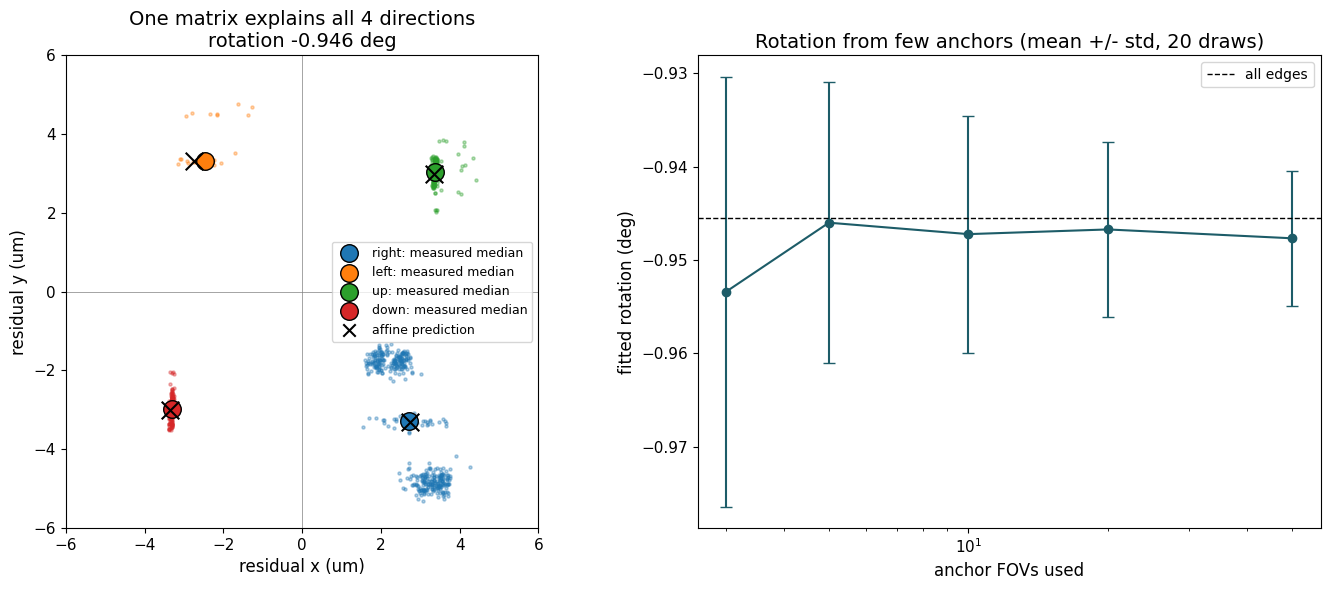

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for dname, col in DIR_COLORS.items():
    s = (edges.direction == dname) & keep
    ax[0].scatter(edges.r[s, 0], edges.r[s, 1], s=5, color=col, alpha=0.35)
    med = np.median(edges.r[s], axis=0); p = np.median(pred[s], axis=0)
    ax[0].scatter(*med, s=160, color=col, edgecolors="k", label=f"{dname}: measured median")
    ax[0].scatter(*p, s=160, marker="x", color="k")
ax[0].scatter([], [], marker="x", color="k", s=80, label="affine prediction")
ax[0].axhline(0, color="gray", lw=0.5); ax[0].axvline(0, color="gray", lw=0.5)
ax[0].set_xlim(-6, 6); ax[0].set_ylim(-6, 6); ax[0].set_aspect("equal")
ax[0].set_xlabel("residual x (um)"); ax[0].set_ylabel("residual y (um)"); ax[0].legend(fontsize=9)
ax[0].set_title(f"One matrix explains all 4 directions\nrotation {rot:+.3f} deg")
g = sweep.groupby("n").rot
ax[1].errorbar(g.mean().index, g.mean(), yerr=g.std(), marker="o", capsize=4, color="#1d5c68")
ax[1].axhline(rot, color="k", ls="--", lw=1, label="all edges")
ax[1].set_xscale("log"); ax[1].set_xlabel("anchor FOVs used"); ax[1].set_ylabel("fitted rotation (deg)")
ax[1].set_title("Rotation from few anchors (mean +/- std, 20 draws)"); ax[1].legend()
fig.tight_layout(); save(fig, "affine_fit")

saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_03_fit_affine/nbhd_corners_nominal_vs_affine.png


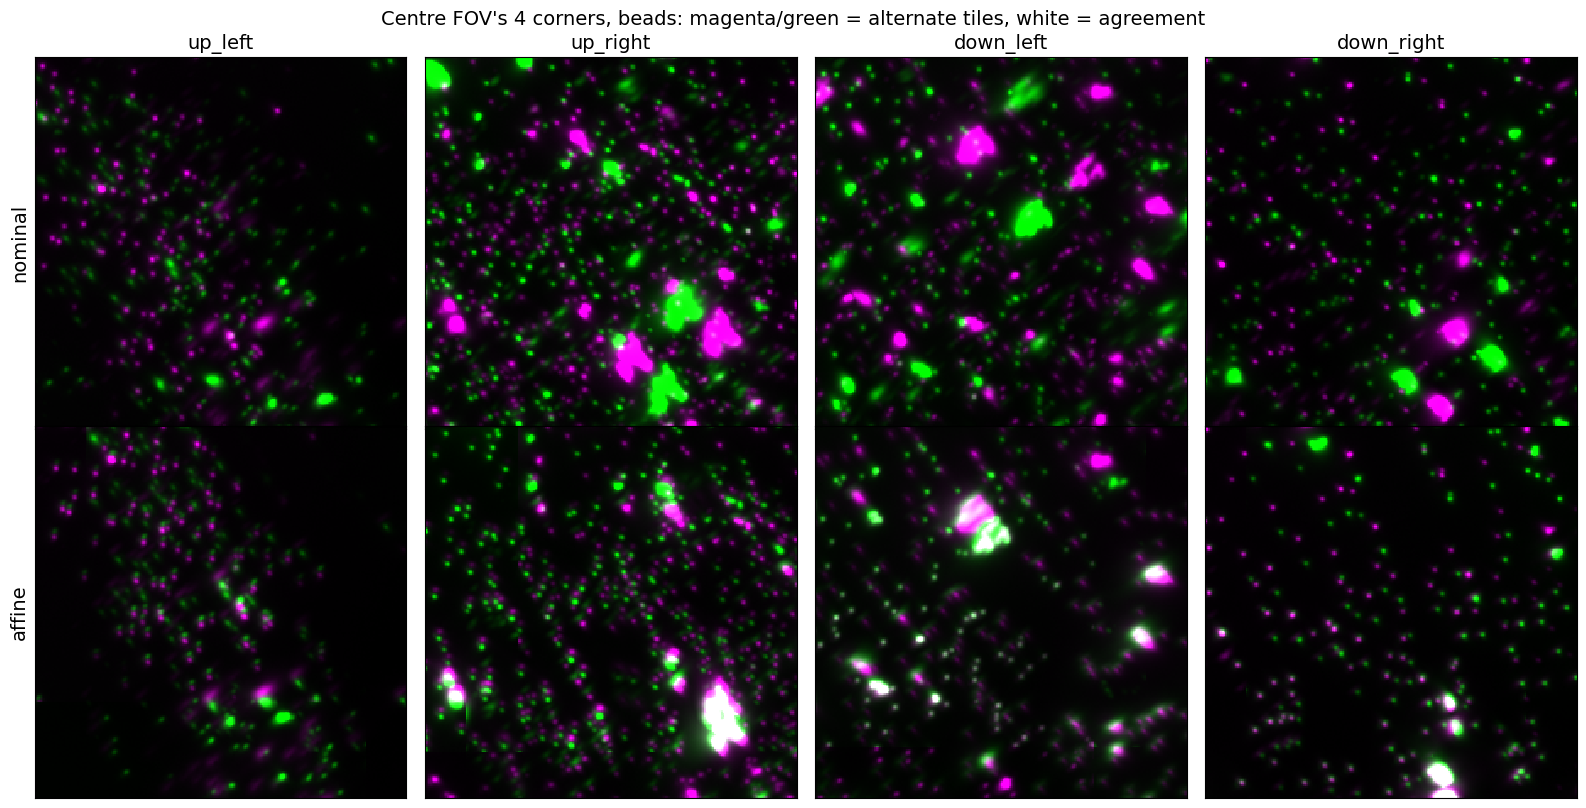

In [8]:
P_aff = L.apply_affine(A, nominal)
fig = corner_views({"nominal": nominal, "affine": P_aff})
fig.suptitle("Centre FOV's 4 corners, beads: magenta/green = alternate tiles, white = agreement", fontsize=TITLE_FS)
fig.tight_layout(); save(fig, "nbhd_corners_nominal_vs_affine")

saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_03_fit_affine/grid_affine_boxes.png


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_03_fit_affine/grid_edge_misfit_nominal_vs_affine.png


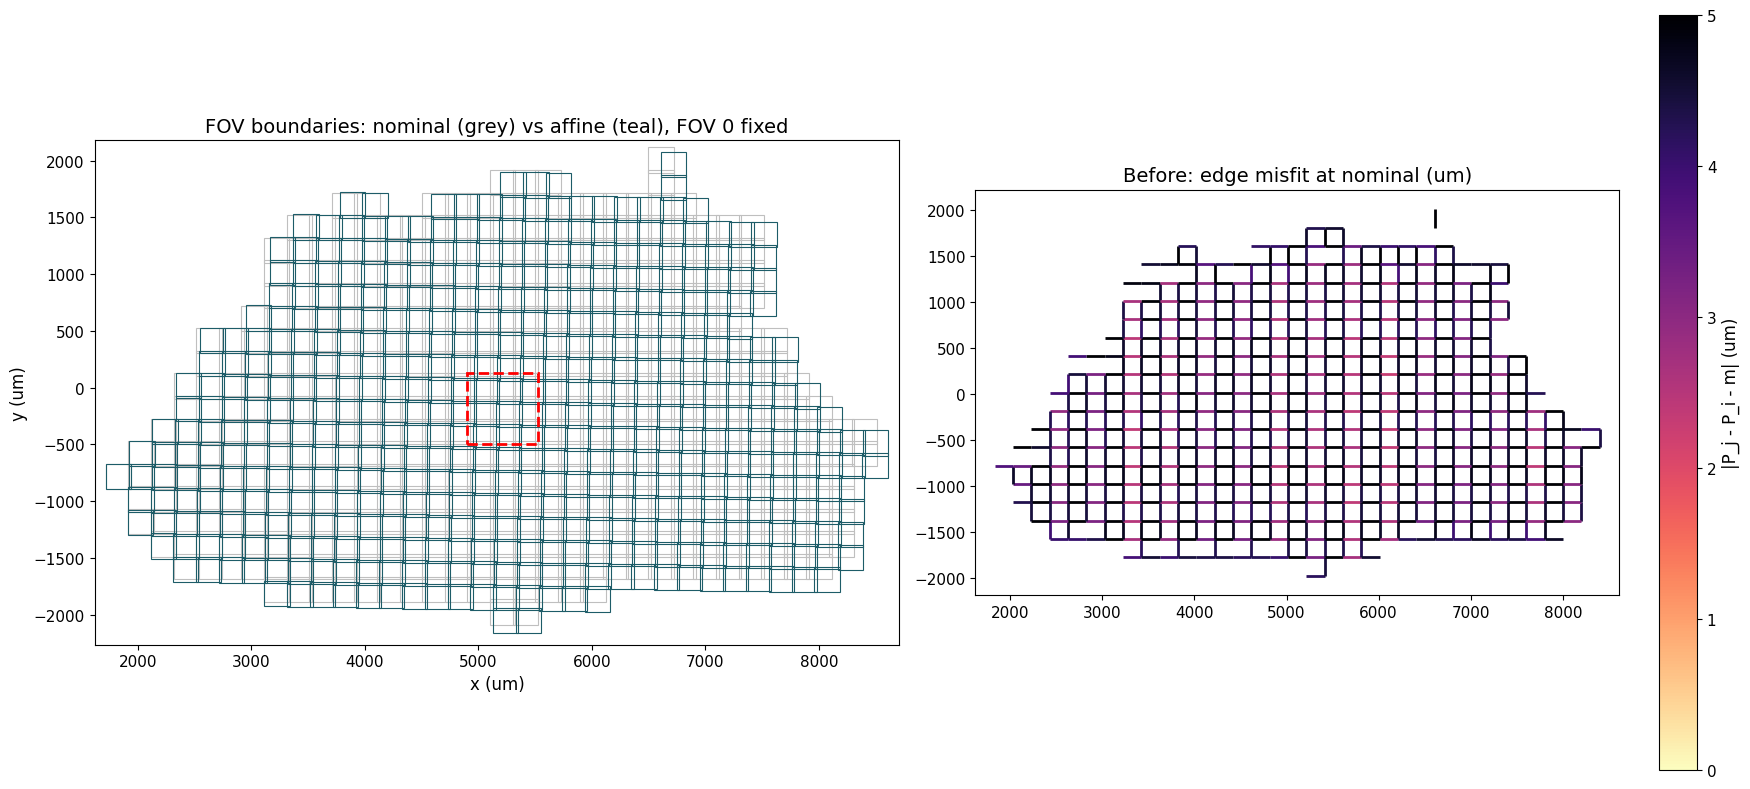

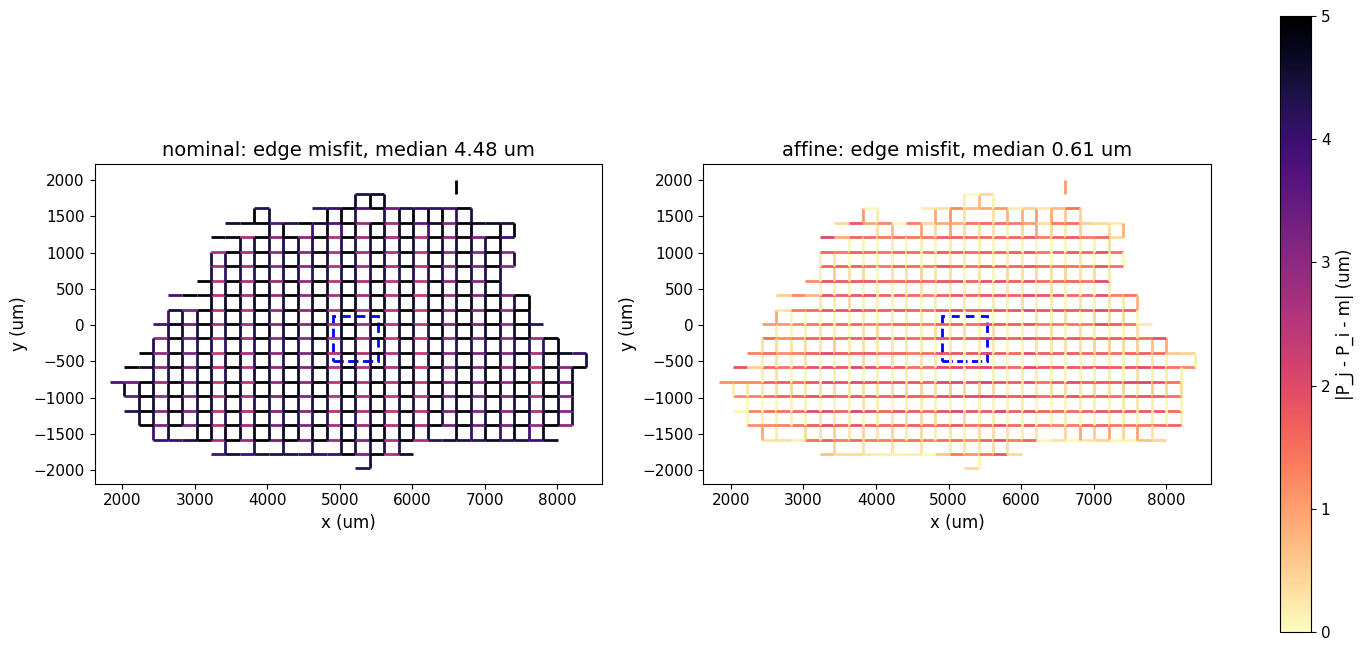

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
draw_boxes(ax[0], nominal, "0.75", lw=0.8)
draw_boxes(ax[0], P_aff, "#1d5c68", lw=0.8)
mark_nbhd(ax[0], nominal, "r")
ax[0].set_title("FOV boundaries: nominal (grey) vs affine (teal), FOV 0 fixed")
ax[0].set_xlabel("x (um)"); ax[0].set_ylabel("y (um)")
vmax = 5
lc = draw_edges(ax[1], nominal, kidx, err_nom, "magma_r", 0, vmax, lw=2)
ax[1].set_title("Before: edge misfit at nominal (um)")
fig.colorbar(lc, ax=ax[1], label="|P_j - P_i - m| (um)")
fig.tight_layout(); save(fig, "grid_affine_boxes")
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
for a, (name, err) in zip(ax, [("nominal", err_nom), ("affine", err_aff)]):
    lc = draw_edges(a, nominal, kidx, err, "magma_r", 0, vmax, lw=2)
    mark_nbhd(a, nominal, "b")
    a.set_title(f"{name}: edge misfit, median {np.median(err):.2f} um"); a.set_xlabel("x (um)"); a.set_ylabel("y (um)")
fig.colorbar(lc, ax=ax, label="|P_j - P_i - m| (um)")
save(fig, "grid_edge_misfit_nominal_vs_affine")

## Notes (numbers quoted by the HTML)

- A = [[1.01373, 0.01687], [-0.01661, 1.01506]]; rotation -0.9455 deg; singular values 1.01521 / 1.01385.
- Rotation alone predicts 3.29 um perpendicular offset per step.
- In-sample edge misfit (kept edges): nominal median 4.484 um, affine 0.612 um.
- Anchor sweep (20 draws): n=3 -0.9534 +/- 0.0230 deg; n=10 -0.9472 +/- 0.0127; n=50 -0.9477 +/- 0.0072.
  Scale 1.0145-1.0147 at every n.